In [14]:
import pandas as pd
from ply.cpp import xrange

from process_raw_data import scope_timestamps
from src import ttl, io
import numpy as np
import pandas
import glob
import os
import matplotlib.pyplot as plt

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/AhmedLab/princess/data/raw'

In [2]:
# set main data path
base_data_path = "/Volumes/AhmedLab/princess/data"
exp = 101

# set experiment file path
raw_path = glob.glob(os.path.join(base_data_path, 'raw', f'*{exp}'))[0]
csv_path = glob.glob(os.path.join(raw_path, '*.csv'))[0]
# load csv file


In [4]:
ttl_csv = ttl.read_csv(csv_path)

In [5]:
ttl_csv

,Time(ms),Scope,Side Camera
0,0.00,0.000610,1.377258
1,0.01,0.000610,3.074036
2,0.02,0.000305,3.203125
3,0.03,0.000610,3.231201
4,0.04,0.000305,3.251648
...,...,...,...
120019797,1200197.97,0.000305,0.084229
120019798,1200197.98,0.000305,0.071411
120019799,1200197.99,0.000610,0.078125
120019800,1200198.00,0.000916,0.083008


In [20]:
scope_timestamps = ttl.extract_2p_relative_timestamps(ttl_csv, threshold=4.5)
camera_timestamps = ttl.extract_camera_relative_timestamps(ttl_csv)
scope_framerate = ttl.get_frame_rate(pd.Series(scope_timestamps))
camera_framerate = ttl.get_frame_rate(pd.Series(camera_timestamps))

(0.0, 100.0)

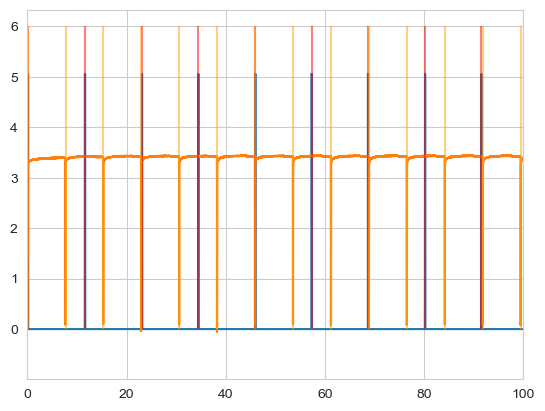

In [27]:
plt.plot(ttl_csv['Time(ms)'], ttl_csv['Scope'])
plt.plot(ttl_csv['Time(ms)'], ttl_csv['Side Camera'])
# plt.plot(ttl_csv['Time(ms)'], scope_timestamps)
plt.vlines(scope_timestamps, 0, 6, colors='red', alpha=0.5)
plt.vlines(camera_timestamps, 0, 6, colors='orange', alpha=0.5)
plt.xlim(0,100)

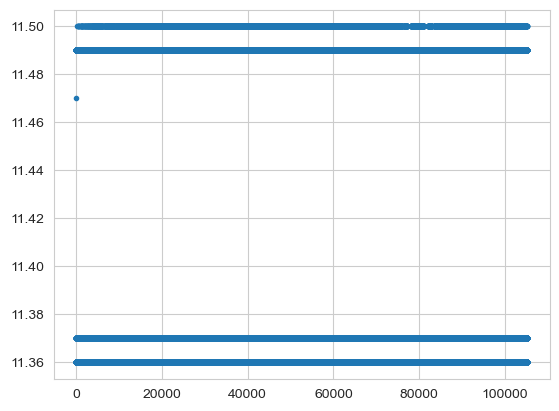

In [35]:
# is there a flyback time?
# in the video, it looks like there should be a flyback time
fr_time = np.diff(scope_timestamps) # in ms
plt.plot(fr_time, marker = '.', linestyle = 'none')


In [3]:
# what if I grab times from the xml
import xml.etree.ElementTree as ET
def read_xml(xml_file_path):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()
    frames = [x.find("Frame") for x in root]
    sequences = [x.find("Sequence") for x in root]
    # my_text = [item.text for item in tree.iter()]
    print(f'Frames: {len(frames)}')
    print(f'Sequences: {len(sequences)}')

In [4]:
xml_file = glob.glob(os.path.join(raw_path, '*.xml'))[0]
xml_data = read_xml(xml_file)

Frames: 2769
Sequences: 2769


In [5]:
tree = ET.parse(xml_file)
root = tree.getroot()
frames = [x.find("Frame") for x in root]
sequences = [x.find("Sequence") for x in root]

In [7]:
root.iter('Frame')

In [10]:
for element in root.iter("Frame"):
    print(element.attrib['absoluteTime'])

37.0683927670001
37.0798073480001
37.0912219290001
37.1026365100001
37.1140510910001
37.1254656720001
37.1368802530001
37.1482948340001
37.1597094150001
37.1711239960001
37.1825385770001
37.1939531580001
37.2053677390001
37.2167823200001
37.2281969010001
37.2396114820001
37.2510260630001
37.2624406440001
37.2738552250001
37.2852698060001
37.2966843870001
37.3080989680001
37.3195135490001
37.3309281300001
37.3423427110001
37.3537572920001
37.3651718730001
37.3765864540001
37.3880010350001
37.3994156160001
37.4108301970001
37.5021468450001
37.5135614260001
37.5249760070001
37.5363905880001
37.5478051690001
37.5592197500001
37.5706343310001
37.5820489120001
37.5934634930001
37.6048780740001
37.6162926550001
37.6277072360001
37.6391218170001
37.6505363980001
37.6619509790001
37.6733655600001
37.6847801410001
37.6961947220001
37.7076093030001
37.7190238840001
37.7304384650001
37.7418530460001
37.7532676270001
37.7646822080001
37.7760967890001
37.7875113700001
37.7989259510001
37.81034053200

In [12]:
frame_starts = []
for element in root.iter("Frame"):
    frame_starts.append(element.attrib['absoluteTime'])

print(len(frame_starts), len(frames))

85777 2769


Notes from parse_bruker_xml.m in Dropbox
get first frame absolute time  and timestamp
2p frame times will be frame absolute time - first frame absolute time
compare this to the first absolute time in voltage recording xml file - this might be different?
Also get z position at each frame


In [ ]:
# get